# ***S100 - Proyecto Final Parte I (Grupo N°8) - Notebook Exploratorio***

#### **Tema:** Fraude en Transacciones con Tarjeta de Crédito
#### **Integrantes:**
*   *Yarlenis Alabarca · 8-959-2219*
*   *Jean Jiménez · 8-978-2274*
*   *Felix Otero · 8-907-2444*
*   *Antoine Villarreal · 4-767-251*

#### **Dataset:** Credit Card Fraud Detection — Tushar Bhadouria (Kaggle)

## ***1. -*** *Importación de Librerías y Carga del DataSet*

In [1]:
import os
import shutil
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

archivos = ["fraudTrain.csv", "fraudTest.csv"]

# Verificando si se encuentran los CSV a utilizar
faltantes = [
    archivo for archivo in archivos
    if not os.path.exists(archivo)
]

if faltantes:
    print("Dataset no encontrado. Descargando desde Kaggle...")

    # KaggleHub descarga en su propia caché
    path = kagglehub.dataset_download(
        "tusharbhadouria/credit-card-fraud-detection"
    )

    # Copiamos únicamente los CSV que hagan falta
    for archivo in faltantes:
        origen = os.path.join(path, archivo)

        if os.path.exists(origen):
            shutil.copy2(origen, archivo)
            print(f"{archivo} copiado a la carpeta actual.")
else:
    print("Dataset ya existe. No es necesario descargarlo.")

# Parámetros para los gráficos a mostrar
AZUL, VERDE, ROJO = "#13294B", "#02B126", "#D40030"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": False, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 10})

# Leyendo el CSV y cargandolo en DataFrame
df = pd.read_csv("fraudTrain.csv")

Dataset ya existe. No es necesario descargarlo.


## ***2. -*** *Revisión General del DataSet*

### **2.1. -** Cantidad de Filas y Columnas

In [2]:
#Mostrando la cantidad de filas y columnas del DataSet
print(f"Filas y columnas: {df.shape}")

Filas y columnas: (1296675, 23)


### **2.2. -** Lista de Columnas

In [3]:
# Mostrando los nombres de cada columna (variable) del DataSet
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

### **2.3. -** Información General del DataSet

In [4]:
# Mostrando información general del DataSet
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

### **Descripción de las columnas**
#### ▶ Información de la transacción
| Variable | Descripción |
|---|---|
| `trans_date_trans_time` | Fecha y hora en que se realizó la transacción |
| `cc_num` | Número único y anonimizado de la tarjeta de crédito |
| `merchant` | Comercio donde se realizó la transacción |
| `category` | Categoría o tipo de comercio/transacción, por ejemplo: viajes, comida o cuidado personal |
| `amt` | Monto de la transacción |
#### ▶ Información del titular de la tarjeta
| Variable | Descripción |
|---|---|
| `first`, `last` | Nombre y apellido del titular de la tarjeta |
| `gender` | Género del titular |
| `street`, `city`, `state`, `zip` | Dirección del titular |
| `lat`, `long` | Ubicación geográfica del titular, expresada en latitud y longitud |
| `city_pop` | Población de la ciudad donde reside el titular |
| `job` | Profesión u ocupación del titular |
| `dob` | Fecha de nacimiento del titular |
### ▶ Identificadores y tiempo
| Variable | Descripción |
|---|---|
| `trans_num` | Identificador único de la transacción |
| `unix_time` | Fecha y hora de la transacción en formato Unix |
#### ▶ Información del comercio
| Variable | Descripción |
|---|---|
| `merch_lat`, `merch_long` | Ubicación geográfica del comercio, expresada en latitud y longitud |
#### ▶ Indicador de fraude
| Variable | Descripción |
|---|---|
| `is_fraud` | Variable objetivo: `1` = fraude, `0` = transacción legítima |


### **2.4. -** Contenido de Primeras Filas

In [5]:
# Eliminando la primera columna ("Unnamed: 0")
df = df.drop(columns=["Unnamed: 0"])

# Mostrando contenido del DataSet para las primeras 5 filas
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


### **2.5. -** Contenido Últimas Filas

In [6]:
# Mostrando contenido del DataSet para las últimas 5 filas
df.tail()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0
1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,Sula,...,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0


### **2.6. -** Estadísticos Generales del DataSet (Valores Numéricos)

In [7]:
# Mostrando resumen estadístico del DataSet
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


## ***3. -*** *Verificando Valores Faltantes o Duplicados* **texto en negrita**

### **3.1. -** Valores Faltantes

In [8]:
#Verificando presencia de valores faltantes en el DataSet
faltantes = df.isna().sum()

nombre_mayor = df.columns[0]
for nombre in df.columns:
    if len(nombre) > len(nombre_mayor):
        nombre_mayor = nombre

# Mostrando cantidad de valores faltantes por columna:
print(f"╔{"═"*59}╗\n║{"":<6}VERIFICACIÓN DE VALORES FALTANTES EN EL DATASET{"":>6}║\n║{"═"*59}║\n"
      f"║{"":<1}-> Cantidad de valores faltantes por columna:{"":>13}║\n║{"-"*59}║")
for columna, valor in faltantes.items():
    print(f"║{"":<4}'{columna}'{"":<{len(nombre_mayor) - len(columna)}} : {valor}{"":>28}║")

# Mostrando porcentaje de valores faltantes por columna:
print(f"║{"-"*59}║\n║{"":<1}-> Porcentaje de valores faltantes por columna:{"":>11}║\n║{"-"*59}║")
for columna, valor in faltantes.items():
    print(f"║{"":<4}'{columna}'{"":<{len(nombre_mayor) - len(columna)}} : {valor / len(df) * 100:.2f}%{"":>24}║")

# Mostrando cantidad y porcentaje total de valores faltantes en todo el DataSet:
print(f"║{"-"*59}║\n║{"":<1}-> Cantidad total de valores faltantes {"":<2}: {faltantes.sum()}{"":>14}║\n"
      f"║{"":<1}-> Porcentaje total de valores faltantes : {faltantes.sum() / len(df) * 100:.2f}%{"":>10}║\n╚{"═"*59}╝")

╔═══════════════════════════════════════════════════════════╗
║      VERIFICACIÓN DE VALORES FALTANTES EN EL DATASET      ║
║═══════════════════════════════════════════════════════════║
║ -> Cantidad de valores faltantes por columna:             ║
║-----------------------------------------------------------║
║    'trans_date_trans_time' : 0                            ║
║    'cc_num'                : 0                            ║
║    'merchant'              : 0                            ║
║    'category'              : 0                            ║
║    'amt'                   : 0                            ║
║    'first'                 : 0                            ║
║    'last'                  : 0                            ║
║    'gender'                : 0                            ║
║    'street'                : 0                            ║
║    'city'                  : 0                            ║
║    'state'                 : 0                            ║
║    'zi

### **3.2. -** Duplicados

In [9]:
# Mostrando cantidad y porcentaje total de valores faltantes en todo el DataSet:
print(f"╔{"═"*60}╗\n║{"":<6}VERIFICACIÓN DE VALORES DUPLICADOS EN EL DATASET{"":>6}║\n║{"═"*60}║\n"
      f"║{"":<1}-> Cantidad de duplicados en el DataSet {"":<2}: {df.duplicated().sum()}{"":>14}║\n"
      f"║{"":<1}-> Porcentaje de duplicados en el DataSet : {df.duplicated().sum() / len(df) * 100:.2f}%{"":>10}║\n╚{"═"*60}╝")

╔════════════════════════════════════════════════════════════╗
║      VERIFICACIÓN DE VALORES DUPLICADOS EN EL DATASET      ║
║════════════════════════════════════════════════════════════║
║ -> Cantidad de duplicados en el DataSet   : 0              ║
║ -> Porcentaje de duplicados en el DataSet : 0.00%          ║
╚════════════════════════════════════════════════════════════╝


## ***4. -*** *Análisis de la Variable Objetivo*

Cantidad de transacciones no fraudulentas   : 1,289,169 
Porcentaje de transacciones no fraudulentas : 99.42%
Cantidad de transacciones fraudulentas      : 7,506 
Porcentaje de transacciones fraudulentas    : 0.58%


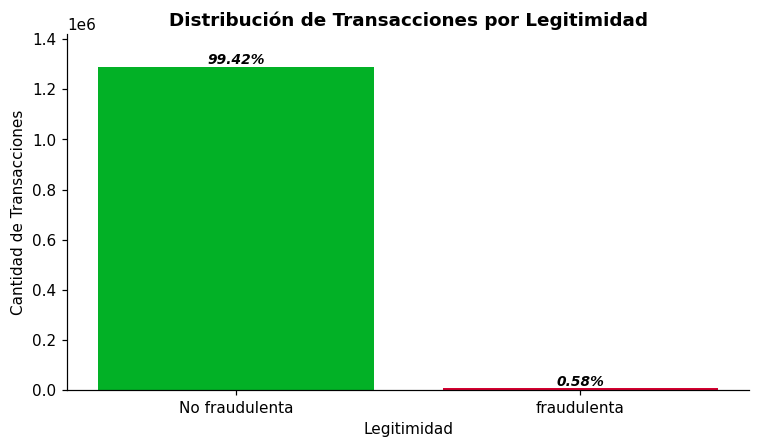

In [10]:
conteo = df["is_fraud"].value_counts().sort_values(ascending=False)

# Mostrando el conteo y el porcentaje de transacciones fraudulentas y no fraudukentas
total_legitimas = conteo[0]
porcentaje_no_fraudulentas = total_legitimas / len(df) * 100
total_fraudes = conteo[1]
porcentaje_fraudulentas = total_fraudes / len(df) * 100
print(f"Cantidad de transacciones no fraudulentas   : {total_legitimas:,.0f} \n"
      f"Porcentaje de transacciones no fraudulentas : {porcentaje_no_fraudulentas:.2f}%\n"
      f"Cantidad de transacciones fraudulentas      : {total_fraudes:,.0f} \n"
      f"Porcentaje de transacciones fraudulentas    : {porcentaje_fraudulentas:.2f}%")

# Mostrando la distribución de la variable "is_fraud" mediante conteo por categoría
plt.bar(["No fraudulenta", "fraudulenta"], conteo.values, color=[VERDE, ROJO])
plt.title("Distribución de Transacciones por Legitimidad")
plt.xlabel("Legitimidad")
plt.ylabel("Cantidad de Transacciones")
for posicion_x, valor in enumerate(conteo.values):
    if posicion_x == 0:
        porcentaje = porcentaje_no_fraudulentas
    else:
        porcentaje = porcentaje_fraudulentas
    plt.text(posicion_x, valor + 0.02, f"{porcentaje:.2f}%", ha="center", va="bottom",
             color="black", fontweight="bold", style="italic", fontsize=9)
plt.ylim(0, conteo.max() * 1.10)
plt.show()

## ***5. -*** *Análisis de Posibles Variables Predictoras*

### **5.1. -** Relación Legitimidad de Transacciones respecto a Hora de la Transacción

In [11]:
# Convirtiendo la fecha de la transacción de formato string a formato datetime
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["Hora"] = df["trans_date_trans_time"].dt.hour
df["Dia"] = df["trans_date_trans_time"].dt.day_name()
df["Nes"] = df["trans_date_trans_time"].dt.month

# Agrupando transacciones en torno a la hora de ejecución de la transacción
fraude_hora = df.groupby("Hora")["is_fraud"].agg(["count", "sum", "mean"])
fraude_hora.columns = ["Transacciones", "Fraudes", "Tasa de fraudes"]
fraude_hora["% tasa de fraudes"] = fraude_hora["Tasa de fraudes"] * 100
fraude_hora["% sobre total fraudes"] = fraude_hora["Fraudes"] / total_fraudes * 100

# Mostrando tabla resumen de legitimidad de transacciones según la hora de ejecución de la transacción
fraude_hora[["Transacciones", "Fraudes", "Tasa de fraudes", "% tasa de fraudes", "% sobre total fraudes"]]

,Transacciones,Fraudes,Tasa de fraudes,% tasa de fraudes,% sobre total fraudes
Hora,,,,,
0,42502,635,0.014940,1.494047,8.459899
1,42869,658,0.015349,1.534909,8.766320
2,42656,625,0.014652,1.465210,8.326672
3,42769,609,0.014239,1.423929,8.113509
4,41863,46,0.001099,0.109882,0.612843
5,42171,60,0.001423,0.142278,0.799361
6,42300,40,0.000946,0.094563,0.532907
7,42203,56,0.001327,0.132692,0.746070
8,42505,49,0.001153,0.115281,0.652811


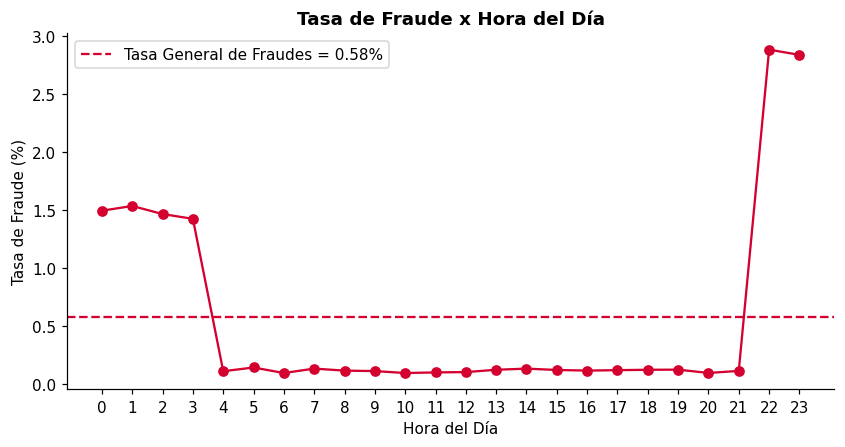

In [12]:
# Mostrando una gráfica sobre la tasa de fraude según la hora de ejecución de la transacción
plt.figure(figsize=(9, 4.2))
plt.plot(fraude_hora.index, fraude_hora["% tasa de fraudes"], marker="o", color=ROJO)
plt.title("Tasa de Fraude x Hora del Día")
plt.xlabel("Hora del Día")
plt.ylabel("Tasa de Fraude (%)")
plt.axhline(porcentaje_fraudulentas, color=ROJO, linestyle="--", label=f"Tasa General de Fraudes = {porcentaje_fraudulentas:.2f}%")
plt.xticks(range(24))
plt.legend()
plt.show()

### **5.2. -** Relación de legitimidad de Transacciones respecto del Canal de Transacción

In [13]:
# Asignando un canal o medio de transacción a cada categoría de comercio
def obtener_canal(categoria):
    if categoria.endswith("_net"):
        return "En línea"
    elif categoria.endswith("_pos"):
        return "Punto de Venta"
    else:
        return "Otro"

df["transaction_channel"] = df["category"].apply(obtener_canal)

# Agrupando transacciones en torno al canal o medio de la transacción
fraude_canal = df.groupby("transaction_channel")["is_fraud"].agg(["count", "sum", "mean"])
fraude_canal.columns = ["Transacciones", "Fraudes", "Tasa de fraudes"]
fraude_canal = fraude_canal.rename_axis("Canal")
fraude_canal["% tasa de fraudes"] = fraude_canal["Tasa de fraudes"] * 100
fraude_canal["% sobre total de fraudes"] = fraude_canal["Fraudes"] / total_fraudes * 100

# Mostrando tabla resumen de legitimidad de transacciones según el canal o medio de la transacción
fraude_canal.sort_values("% sobre total de fraudes", ascending=False)

,Transacciones,Fraudes,Tasa de fraudes,% tasa de fraudes,% sobre total de fraudes
Canal,,,,,
Punto de Venta,319965,2836,0.008863,0.886347,37.783107
En línea,206282,2762,0.013389,1.338944,36.797229
Otro,770428,1908,0.002477,0.247655,25.419664


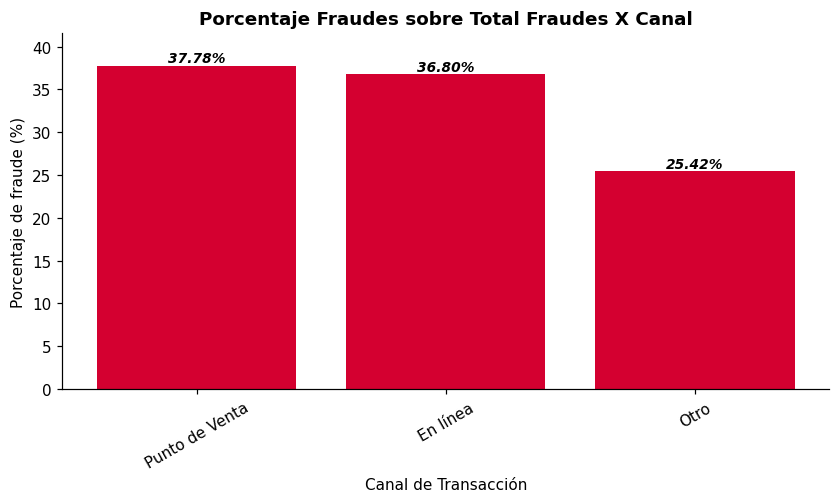

In [14]:
# Mostrando una gráfica sobre la tasa de fraude según el canal o medio de la transacción
fraude_canal = fraude_canal.sort_values("% sobre total de fraudes", ascending=False)

plt.figure(figsize=(9, 4.2))
plt.bar(fraude_canal.index, fraude_canal["% sobre total de fraudes"], color=ROJO)
plt.title("Porcentaje Fraudes sobre Total Fraudes X Canal")
plt.xlabel("Canal de Transacción")
plt.ylabel("Porcentaje de fraude (%)")
plt.xticks(range(3), rotation=30)
for posicion_x, valor in enumerate(fraude_canal["% sobre total de fraudes"].values):
    plt.text(posicion_x, valor + 0.02, f"{valor:.2f}%", ha="center", va="bottom",
             color="black", fontweight="bold", style="italic", fontsize=9)
plt.ylim(0, fraude_canal["% sobre total de fraudes"].max() * 1.10)
plt.show()

### **5.3. -** Relación de Legitimidad de Transacciones respecto del Monto de *Transacción*

In [15]:
# Agrupando los montos de transacción individuales en cuartiles con cantidades similares de observaciones
df["Monto de transacción"] = pd.qcut(df["amt"], q=4,
    labels=[
        "Monto bajo",
        "Monto medio - bajo",
        "Monto medio - alto",
        "Monto alto"
    ], duplicates="drop"
)

# Agrupando transacciones en torno al nivel de monto de la transacción
fraude_monto = df.groupby("Monto de transacción", observed=False)["is_fraud"].agg(["count", "sum", "mean"])
fraude_monto.columns = ["Transacciones", "Fraudes", "Tasa de fraudes"]
fraude_monto["% tasa de fraudes"] = fraude_monto["Tasa de fraudes"] * 100
fraude_monto["% sobre total de fraudes"] = fraude_monto["Fraudes"] / total_fraudes * 100

# Mostrando tabla resumen de legitimidad de transacciones según el nivel de monto de la transacción
fraude_monto.sort_values("% sobre total de fraudes", ascending=False)

,Transacciones,Fraudes,Tasa de fraudes,% tasa de fraudes,% sobre total de fraudes
Monto de transacción,,,,,
Monto alto,324112,5860,0.018080,1.808017,78.070877
Monto medio - bajo,324087,1104,0.003406,0.340649,14.708233
Monto bajo,324325,461,0.001421,0.142141,6.141753
Monto medio - alto,324151,81,0.000250,0.024988,1.079137


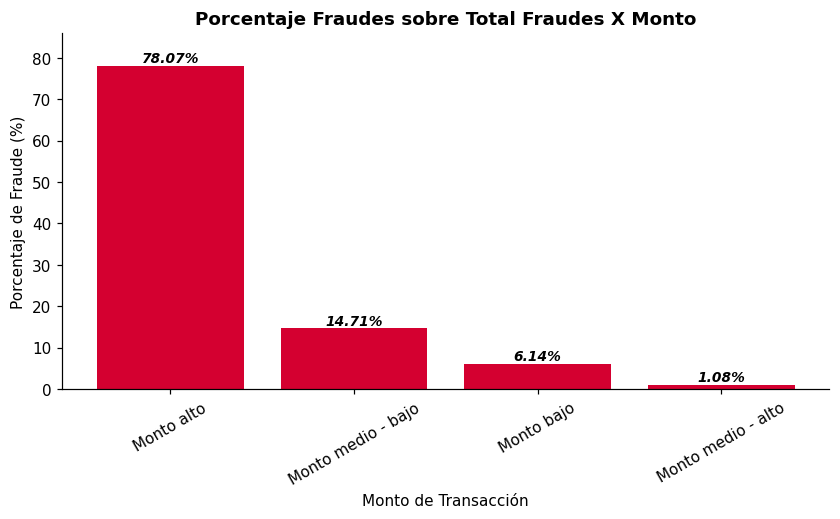

In [16]:
# Mostrando una gráfica sobre la tasa de fraude según el monto de la transacción
fraude_monto = fraude_monto.sort_values("% sobre total de fraudes", ascending=False)
plt.figure(figsize=(9, 4.2))
plt.bar(fraude_monto.index, fraude_monto["% sobre total de fraudes"], color=ROJO)
plt.title("Porcentaje Fraudes sobre Total Fraudes X Monto")
plt.xlabel("Monto de Transacción")
plt.ylabel("Porcentaje de Fraude (%)")
plt.xticks(range(4), rotation=30)
for posicion_x, valor in enumerate(fraude_monto["% sobre total de fraudes"].values):
    plt.text(posicion_x, valor + 0.02, f"{valor:.2f}%", ha="center", va="bottom",
             color="black", fontweight="bold", style="italic", fontsize=9)
plt.ylim(0, fraude_monto["% sobre total de fraudes"].max() * 1.10)
plt.show()

### **5.4. -** Relación de Legitimidad de Transacciones respecto de la Categoría de **Comercio**

In [17]:
# Agrupando transacciones en torno al tipo de comercio donde se efectúa de la transacción
fraude_categoria = df.groupby("category")["is_fraud"].agg(["count", "sum", "mean"])
fraude_categoria.columns = ["Transacciones", "Fraudes", "Tasa de fraudes"]
fraude_categoria = fraude_categoria.rename_axis("Categoría")
fraude_categoria["% tasa de fraude"] = fraude_categoria["Tasa de fraudes"] * 100
fraude_categoria["% sobre total de fraudes"] = fraude_categoria["Fraudes"] / total_fraudes * 100

# Mostrando tabla resumen de legitimidad de transacciones según el tipo de comercio donde se efectúa de la transacción
fraude_categoria.sort_values("% sobre total de fraudes", ascending=False)

,Transacciones,Fraudes,Tasa de fraudes,% tasa de fraude,% sobre total de fraudes
Categoría,,,,,
grocery_pos,123638,1743,0.014098,1.409761,23.221423
shopping_net,97543,1713,0.017561,1.756149,22.821743
misc_net,63287,915,0.014458,1.445795,12.190248
shopping_pos,116672,843,0.007225,0.722538,11.231015
gas_transport,131659,618,0.004694,0.469394,8.233413
misc_pos,79655,250,0.003139,0.313853,3.330669
kids_pets,113035,239,0.002114,0.211439,3.184119
entertainment,94014,233,0.002478,0.247835,3.104183
personal_care,90758,220,0.002424,0.242403,2.930989


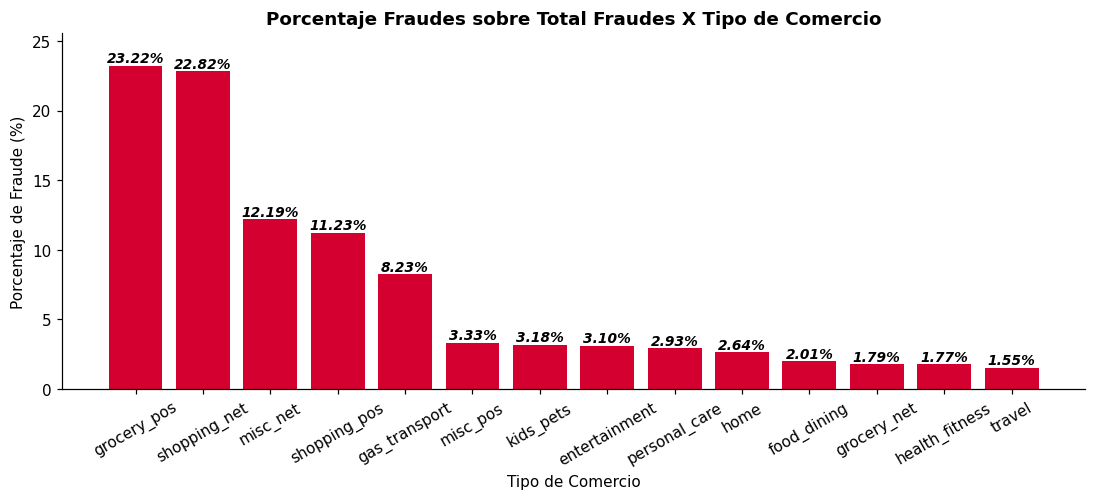

In [18]:
# Mostrando una gráfica sobre la tasa de fraude según el tipo de comercio donde se efectúa de la transacción
fraude_categoria = fraude_categoria.sort_values("% sobre total de fraudes", ascending=False)

plt.figure(figsize=(12, 4.2))
plt.bar(fraude_categoria.index, fraude_categoria["% sobre total de fraudes"], color=ROJO)
plt.title("Porcentaje Fraudes sobre Total Fraudes X Tipo de Comercio")
plt.xlabel("Tipo de Comercio")
plt.ylabel("Porcentaje de Fraude (%)")
plt.xticks(range(14), rotation=30)
for posicion_x, valor in enumerate(fraude_categoria["% sobre total de fraudes"].values):
    plt.text(posicion_x, valor + 0.02, f"{valor:.2f}%", ha="center", va="bottom",
             color="black", fontweight="bold", style="italic", fontsize=9)
plt.ylim(0, fraude_categoria["% sobre total de fraudes"].max() * 1.10)
plt.show()

### **5.5. -** Relación de Legitimidad de Transacciones respecto de la Razón entre Monto de Transacción y Promedio de Monto por Tarjeta

In [19]:
# Obteniendo el promedio de montos por tarjeta de crédito
promedio_tarjeta = df.groupby("cc_num")["amt"].transform("mean")

# Obteniendo la razón entre monto de transacción y promedio de montos por tarjeta de crédito
df["amt_vs_customer_avg"] = df["amt"] / promedio_tarjeta

# Agrupando la legitimidad de las transacciones en torno a la razón entre monto de transacción y promedio de montos por tarjeta de crédito
fraude_prom_trans = df.groupby("is_fraud")["amt_vs_customer_avg"].agg(["count", "mean", "median", "min", "max"])
fraude_prom_trans.columns = ["Transacciones", "Media", "Mediana", "Mín", "Máx"]
fraude_prom_trans = fraude_prom_trans.rename_axis("Es fraude")

# Mostrando tabla resumen de la razón monto de transacción/promedio de montos según la legitimidad de la transacción
fraude_prom_trans.sort_values("Media", ascending=False)

,Transacciones,Media,Mediana,Mín,Máx
Es fraude,,,,,
1,7506,6.912082,5.184560,0.008693,23.912014
0,1289169,0.965578,0.666258,0.008779,386.481588


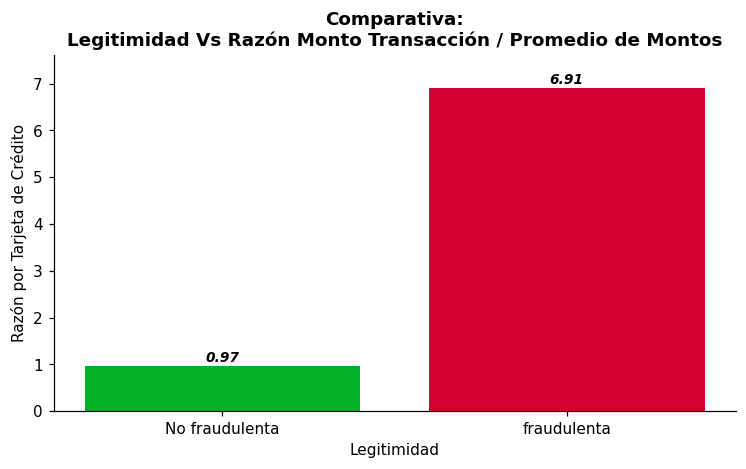

In [20]:
# Mostrando una gráfica sobre la comparativa del monto de las transacciones vs el promedio de montos para una tarjeta de crédito
plt.bar(["No fraudulenta", "fraudulenta"], fraude_prom_trans["Media"], color=[VERDE, ROJO])
plt.title("Comparativa:\nLegitimidad Vs Razón Monto Transacción / Promedio de Montos")
plt.xlabel("Legitimidad")
plt.ylabel("Razón por Tarjeta de Crédito")
for posicion_x, valor in enumerate(fraude_prom_trans["Media"].values):
    plt.text(posicion_x, valor + 0.02, f"{valor:.2f}", ha="center", va="bottom",
             color="black", fontweight="bold", style="italic", fontsize=9)
plt.ylim(0, fraude_prom_trans["Media"].max() * 1.10)
plt.show()